# Step 1 : Mengenal lebih dekat Dataset
> 🎯 **Tujuan Pembelajaran**
> - Memahami apa itu `DataFrame` (tabel data di Python).
> - Membuka & membaca data dengan **pandas**.
> - Melihat ringkasan data: `head`, `shape`, `info`, `describe`.
> - Memfilter & menghitung data sederhana.
> - Membuat visualisasi pertama untuk memahami data.


# Tentang Dataset

memakai **Iris Dataset**, salah satu dataset paling terkenal di dunia Machine Learning.
Dataset ini berisi pengukuran 150 bunga iris dari 3 spesies berbeda.

- **Sumber:** [Kaggle — uciml/iris](https://www.kaggle.com/datasets/uciml/iris)
- **Jumlah data:** 150 baris × 6 kolom

| Kolom | Arti |
|-------|------|
| `Id` | Nomor urut bunga |
| `SepalLengthCm` | Panjang kelopak (sepal) dalam cm |
| `SepalWidthCm` | Lebar kelopak (sepal) dalam cm |
| `PetalLengthCm` | Panjang mahkota (petal) dalam cm |
| `PetalWidthCm` | Lebar mahkota (petal) dalam cm |
| `Species` | Jenis bunga: *setosa*, *versicolor*, *virginica* |

# Import Dataset dan Library


Saya menarik data langsung dari situs Kaggle


In [3]:
# Instal Kaggle
!pip install -q kaggle

# Pastikan file kaggle.json sudah di-upload ke Colab
# Jalankan perintah ini untuk mendownload dan unzip otomatis
!kaggle datasets download -d uciml/iris --unzip

Dataset URL: https://www.kaggle.com/datasets/uciml/iris
License(s): CC0-1.0
100% 3.60k/3.60k [00:00<00:00, 9.21MB/s]



Penggunaan Library


- **pandas** → membaca & mengolah data berbentuk tabel.
- **numpy** → operasi angka/array.
- **matplotlib** & **seaborn** → membuat grafik.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Explorasi Awal

In [11]:
# Pengaturan tampilan grafik
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv('Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Setiap baris adalah profil fisik satu bunga. Bagi saya, ini adalah "sidik jari" numerik:

- Identitas: Id (nomor urut) dan Species (nama bunga).

- Dimensi: Kombinasi empat angka (Sepal dan Petal) yang mendefinisikan bentuk uniknya.

Saya membaca angka-angka ini untuk mengenali pola. Jika saya melihat bunga baru, saya membandingkan ukurannya dengan pola yang sudah saya hafal di data ini untuk memprediksi jenisnya.

In [13]:
#Ukuran Data : ( Jumlah Baris dan Kolom )

print("Bentuk Data:", df.shape)

Bentuk Data: (150, 6)


terdapat 150 baris data (bunga) dan 6 kolom (atribute)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


dari .info(). diketahui :    


*   Tidak terdapat Missing Value dalam dataset Iris, 150 Data NonNull
*   Terdapat beberapa tipe data ( ID(Int), Feature Attribute(Float) dan Target (String) )
*   Data ini sudah bersih



In [15]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


dari .describe() diketahui :     

*   Jumlah total
*   Rata-Rata (Mean)
*   Standar Deviasi ( Std )
*   Min Value
*   Max Value


Contoh : SepalWidth


*   Mean ( 3.05 cm )
*   Min-Max ( 2.0 - 4.4 cm )
*   std ( 0.43 cm )

In [17]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


dari .isnull().sum() diketahui :    

*   Dalam dataset tidak terdapat data yang hilang

# Menghitung dan Memfilter Data

In [21]:
#Menghitung Jumlah bunga pada tiap Spesies
df['Species'].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


dari .valuecount() , diketahui :

- masing masing spesies memiliki jumlah data yang sama
- dataset balanced masing masing spesies memiliki 50 data

In [25]:
#Filter Spesies Bunga dengan Panjang

length_petal = df[df['PetalLengthCm'] > 5]

print(f"Jumlah bunga dengan PetalLength > 5 cm: {len(length_petal)}")

length_petal["Species"].value_counts()

Jumlah bunga dengan PetalLength > 5 cm: 42


,count
Species,
Iris-virginica,41
Iris-versicolor,1


- Bungan dengan panjang pental lebih dari 5 cm, hampir mayoritas berjenis *Virginica* dan minoritas *versicolor*.

- dengan ini kita dapat berasumsi sementara bahwa ukuran panjang petal bisa memisahkan spesies

In [56]:
df.groupby('Species').mean()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,,
Iris-setosa,25.5,5.006,3.418,1.464,0.244
Iris-versicolor,75.5,5.936,2.770,4.260,1.326
Iris-virginica,125.5,6.588,2.974,5.552,2.026


dari .groupby('Species').mean() , kita bisa melihat bahwa :    
-  rata rata petalwidth dan petallength Iris sentosa paling kecil diantara 2 lainnya
- rata rata petalwidth dan petallength Iris Virginica paling besar diantara 2 lainnya
- berdasarkan rata rata bisa dibuat hipotesis bahwa petallength dan petalwidht mempengaruhi jenis species

# Exploratory Data Analisis dan Visualisasi Data


Explorasi awal melihat statistik data sudah dilakukan, sekarang saatnya melihat Visualisasi Data untuk memahami pola data lebih lanjut

## a) Distribusi Tiap Fitur( Histogram )

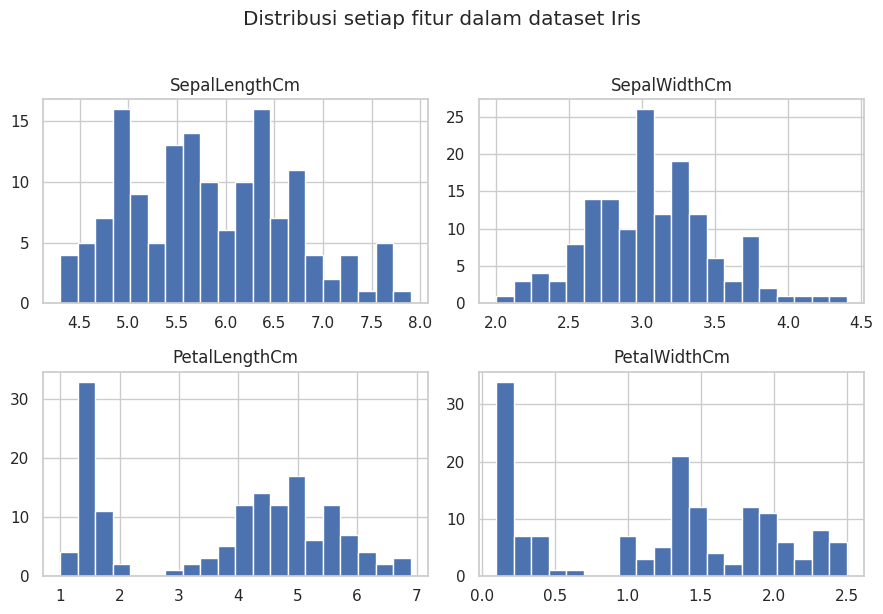

In [32]:
#menghapus kolom 'id' & Membuat Histogram masing masing fitur dengan setiap fitur memiliki 20 Bins
df.drop('Id', axis=1).hist(bins=20, figsize=(9, 6))

plt.suptitle('Distribusi setiap fitur dalam dataset Iris', y=1.02)
plt.tight_layout()
plt.show()

- **SepalLengthCm**: Distribusi terlihat cukup menyebar, dengan beberapa puncak, menunjukkan adanya variasi dalam panjang kelopak.

- **SepalWidthCm**: Distribusi ini cenderung normal, dengan sebagian besar data terkonsentrasi di sekitar nilai tengah, sekitar 3.0 cm.

- **PetalLengthCm**: Ini menunjukkan distribusi bimodal yang sangat jelas, dengan satu kelompok bunga memiliki panjang mahkota yang sangat pendek (sekitar 1-2 cm) dan kelompok lain memiliki panjang mahkota yang lebih panjang (sekitar 4-5 cm). Ini adalah indikasi kuat bahwa ada lebih dari satu spesies dalam dataset yang memiliki karakteristik panjang mahkota yang berbeda.


- **PetalWidthCm**: Mirip dengan PetalLengthCm, distribusi lebar mahkota juga bimodal, dengan satu kelompok memiliki lebar mahkota sangat kecil (sekitar 0-0.5 cm) dan kelompok lain memiliki lebar mahkota yang lebih besar (sekitar 1.2-1.8 cm). Ini juga mendukung dugaan adanya perbedaan spesies berdasarkan lebar mahkota.

## b) Jumlah Data per Species ( Countplot )

/tmp/ipykernel_1156/1916735173.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Species', palette="viridis")


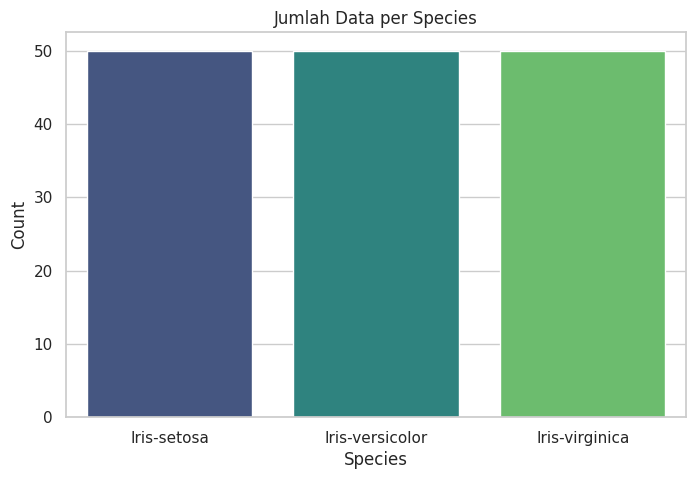

In [37]:
sns.countplot(data=df, x='Species', palette="viridis")
plt.title('Jumlah Data per Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

**Interpretasi**: grafik memperlihatkan dataset ini balanced ( 50 data per Species )

## c) Hubungan Antar Fitur ( SepalLength dengan PetalLength)(ScatterPlot)

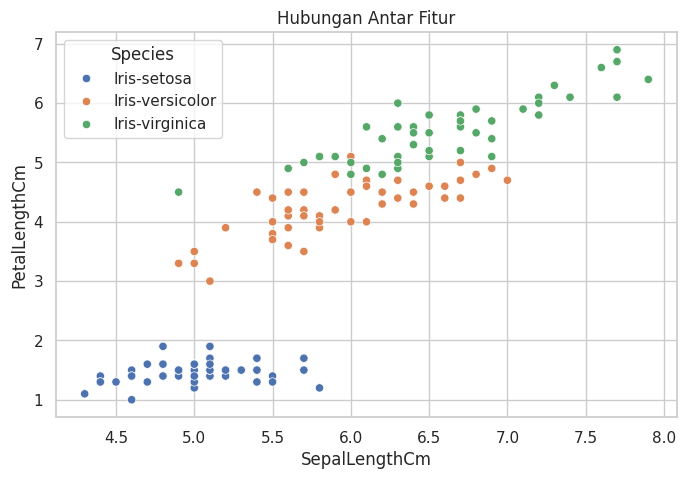

In [39]:
sns.scatterplot(data=df, x='SepalLengthCm', y='PetalLengthCm', hue='Species')
plt.title('Hubungan Antar Fitur')
plt.xlabel('SepalLengthCm')
plt.ylabel('PetalLengthCm')
plt.show()

**Interpretasi**:
- Kelompok IRIS-SETOSA dikiri bawah terlihat jelas terpisah dari 2 kelompok lain
- IRIS-Virginica dan IRIS-Versicolor terlihat sedikit tumpang tindih
- Berdasarkan Data yang dilihat dan diamati kita bisa menggunakan algoritma klasifikasi untuk menyelesaikan masalah ini

## d) Hubungan Antar Fitur ( SepalWidth dengan PetalWidth )(ScatterPlot)

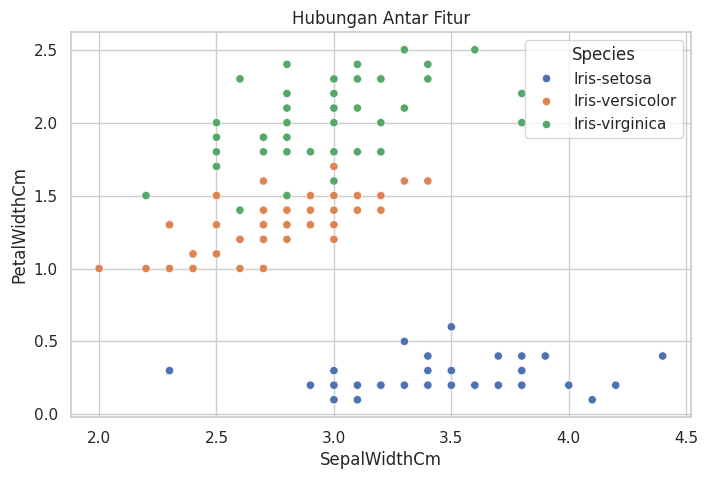

In [40]:
sns.scatterplot(data=df, x='SepalWidthCm', y='PetalWidthCm', hue='Species')
plt.title('Hubungan Antar Fitur')
plt.xlabel('SepalWidthCm')
plt.ylabel('PetalWidthCm')
plt.show()

**Interpretasi**:
- Kelompok IRIS-SETOSA dikanan bawah terlihat jelas terpisah dari 2 kelompok lain
- IRIS-Virginica dan IRIS-Versicolor terlihat sedikit tumpang tindih
- Berdasarkan Data yang dilihat dan diamati kita bisa menggunakan algoritma klasifikasi untuk menyelesaikan masalah ini

**Interpretasi**:

Dari 2 pengamatan diatas disimpulkan sementara
-  Karakteristik Iris-Sentosa ( memimili SepalLenght dan PetalWidth paling kecil )
-  Karakteristik Iris-Virginica ( Memiliki PetalLenght dan PetalWidth paling tinggi )
-  Karakteristik Iris-Versicolor (Memiliki PetalLenght dan PetalWidth diantara Iris-Sentosa dan Iris-Virginica)

## e) Perbandingan Ukuran antar Spesies( BoxPlot )

/tmp/ipykernel_1156/1632725179.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Species', y='PetalWidthCm', palette="viridis")


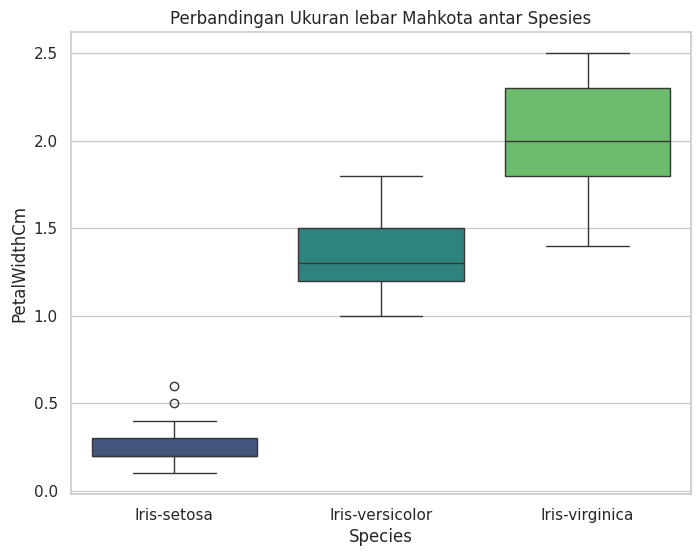

In [54]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Species', y='PetalWidthCm', palette="viridis")
plt.title('Perbandingan Ukuran lebar Mahkota antar Spesies')
plt.xlabel('Species')
plt.ylabel('PetalWidthCm')
plt.show()

**Interpretasi**:
- Iris Sentosa Memiliki Lebar Petal paling kecil.
- Iris-Virginica Memiliki Lebar Petal paling Lebar.

/tmp/ipykernel_1156/3568346364.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  SNS = sns.boxplot(data=df, x='Species', y='PetalLengthCm', palette="viridis")


Text(0, 0.5, 'PetalLengthCm')

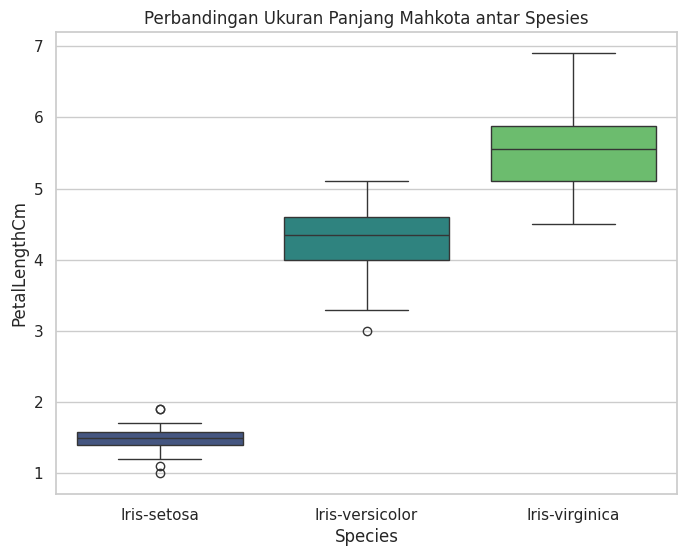

In [53]:
plt.figure(figsize=(8, 6))
SNS = sns.boxplot(data=df, x='Species', y='PetalLengthCm', palette="viridis")
plt.title('Perbandingan Ukuran Panjang Mahkota antar Spesies')
plt.xlabel('Species')
plt.ylabel('PetalLengthCm')

**Interpretasi**:
- Iris-Sentosa Memiliki kriteria Panjang Petal paling Pendek.
- Iris-Virginica Memiliki kriteria Panjang Petal paling Panjang.

/tmp/ipykernel_1156/964833644.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  SNS = sns.boxplot(data=df, x='Species', y='SepalLengthCm', palette="viridis")


Text(0, 0.5, 'SepalLengthCm')

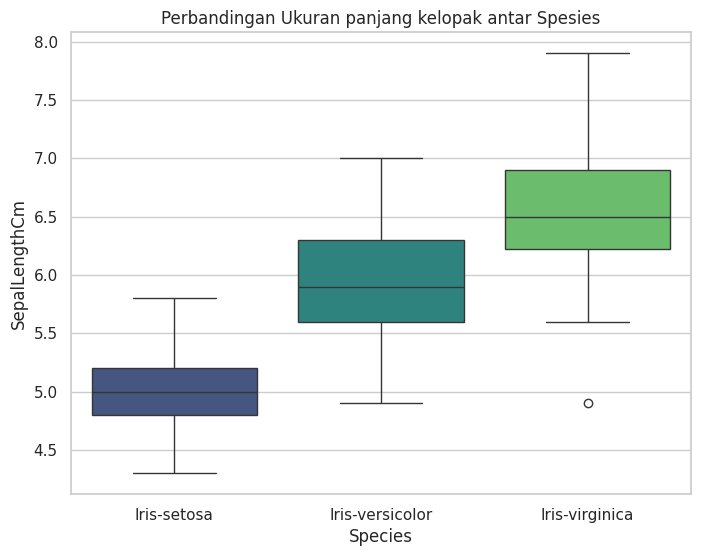

In [51]:
plt.figure(figsize=(8, 6))
SNS = sns.boxplot(data=df, x='Species', y='SepalLengthCm', palette="viridis")
plt.title('Perbandingan Ukuran panjang kelopak antar Spesies')
plt.xlabel('Species')
plt.ylabel('SepalLengthCm')

**Interpretasi**:
- Iris-Sentosa Memiliki kriteria Panjang kelopak paling Pendek.
- Iris-Virginica Memiliki kriteria Panjang kelopak paling Panjang.

/tmp/ipykernel_1156/3016894977.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  SNS = sns.boxplot(data=df, x='Species', y='SepalWidthCm', palette="viridis")


Text(0, 0.5, 'SepalWidthCm')

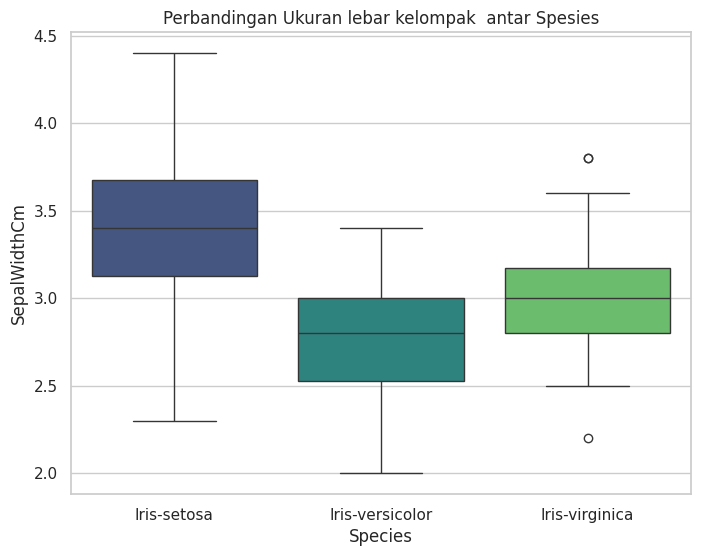

In [52]:
plt.figure(figsize=(8, 6))
SNS = sns.boxplot(data=df, x='Species', y='SepalWidthCm', palette="viridis")
plt.title('Perbandingan Ukuran lebar kelompak  antar Spesies')
plt.xlabel('Species')
plt.ylabel('SepalWidthCm')

**Interpretasi**:
- Iris-Sentosa Memiliki kriteria lebar kelopak paling besar 3.1 s/d 3.6 cm
- Iris-Virginicad dan Versicolor memiliki kriteria lebar kelopak dari 2 s/s 3.1 cm

## f) Semua pasangan Fitur Sekaligus (Pairplot)

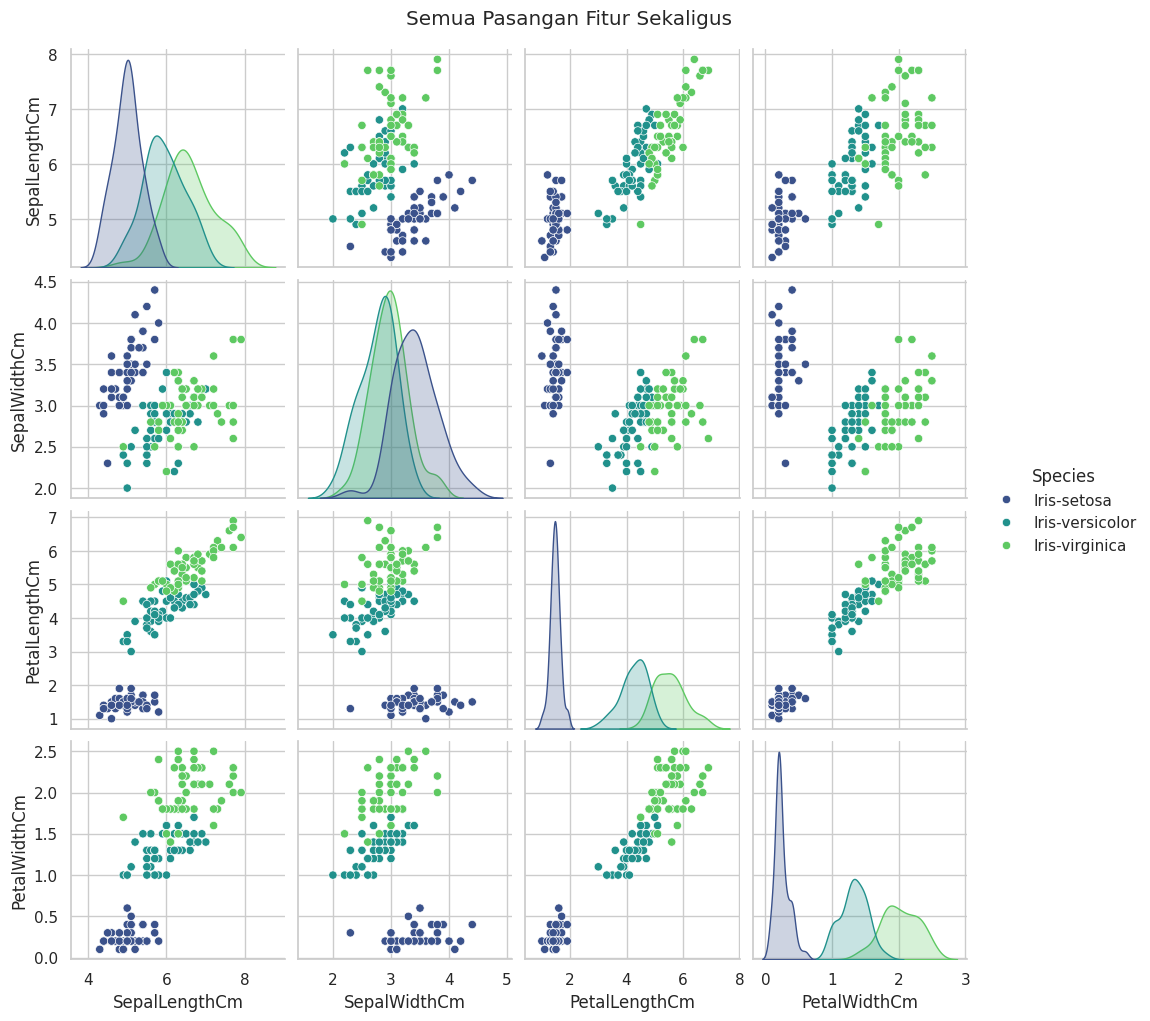

In [55]:
sns.pairplot(df.drop('Id', axis=1), hue='Species', palette="viridis")
plt.suptitle('Semua Pasangan Fitur Sekaligus', y=1.02)
plt.show()

**Interpretasi**:
- Pasangan PetalWidth dan PetalLenght ( Memisahkan 3 spesies ini dengan rapih dan jelas )
- Pasangan PetalWidth dan SepalLenght ( Memisahkan 3iris sentosa dengan jelas dan iris-virginica,versicolor saling bertumpuk secara irisan dengan jelas )
- Pasangan PetalWidth dan SepalWidth ( Memisahkan 3iris sentosa dengan jelas dan iris-virginica,versicolor saling bertumpuk secara irisan dengan jelas )

# Kesimpulan dan Insight

- Dataset ini sudah balanced, dan bersih ( terdapat 150 baris dan tidak ada missing value )
- Ukuran Mahkota atau petal ( Panjang dan Lebar ) adalah pembeda spesies paling kuat
- untuk iris-sentosa mudah diklasifikasikan, dan iris-virginica dan versicolor butuh usaha lebih untuk diklasifikasikan
- alur kerja diatas adalah sebagai berikut:
    1.  Import Library
    2.  load dataset
    3.  Statistic View
    4.  Exploraroty Data Analytic
    5.  Explainatory Data Analytic Using Visualization

- Kesimpulan dan Insight

## Insight dan Kaitan Real Case
Pola yang kita temukan — **beberapa fitur sederhana ternyata cukup memisahkan kelas** —
adalah inti banyak proyek nyata: alih-alih memakai semua kolom, kita cari segelintir fitur
paling informatif (di sini: ukuran petal). Cara berpikir ini menghemat biaya pengumpulan
data dan membuat model lebih ringan serta mudah dijelaskan.

### ⚠️ Jebakan Data
Kolom `Id` hanya **nomor urut**, bukan hasil pengukuran. Jangan pernah memasukkannya
sebagai fitur model — angka urut yang kebetulan terkait label bisa membuat model "curang"
dan akurasinya menyesatkan. Selalu pisahkan kolom identitas dari fitur sebenarnya.